In [4]:
# =============================================================================
# 셀 1: 환경 설정 / SSOT 경로 / 유틸리티
# 목적: 다른 컴퓨터에서도 .env 기반으로 동일 환경 재현
# 산출물: 경로 변수, 로거, 유틸 함수
# 주의: .env 파일에 QP2_ROOT 반드시 설정되어 있어야 함
# =============================================================================

import os, sys, logging, json, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from dotenv import load_dotenv

# ── .env 로드 ──
load_dotenv()
QP2_ROOT = Path(os.environ["QP2_ROOT"])

# ── SSOT 경로 ──
DATA_DIR      = QP2_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
INTERIM_DIR   = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
META_DIR      = DATA_DIR / "meta"
SEC_RAW_DIR   = RAW_DIR  / "sec" / "companyfacts"

# ── Finnhub 설정 ──
FINNHUB_API_KEY = os.environ.get("FINNHUB_API_KEY", "d5u2mfpr01qtjet1q8bgd5u2mfpr01qtjet1q8c0")

# ── 로거 ──
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("P7_NSI")

# ── 유틸 함수 ──
def save_parquet(df: pd.DataFrame, path: Path, **kwargs):
    """parquet 저장 + 로그"""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False, **kwargs)
    logger.info(f"Saved {path.name}  rows={len(df)}")

def winsorize(s: pd.Series, lower=0.01, upper=0.99) -> pd.Series:
    """양쪽 극단 클리핑"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df: pd.DataFrame, col: str) -> pd.Series:
    """날짜별 횡단면 z-score"""
    g = df.groupby("date")[col]
    return (df[col] - g.transform("mean")) / g.transform("std")

# ── 경로 확인 ──
assert QP2_ROOT.exists(),       f"QP2_ROOT 없음: {QP2_ROOT}"
assert SEC_RAW_DIR.exists(),    f"SEC companyfacts 없음: {SEC_RAW_DIR}"
assert META_DIR.exists(),       f"META_DIR 없음: {META_DIR}"

logger.info(f"QP2_ROOT       = {QP2_ROOT}")
logger.info(f"SEC_RAW_DIR    = {SEC_RAW_DIR}")
logger.info(f"FINNHUB_API_KEY= {FINNHUB_API_KEY[:8]}...")
logger.info("셀 1 완료 — 환경 준비 OK")

16:12:18 [INFO] QP2_ROOT       = C:\QP2
16:12:18 [INFO] SEC_RAW_DIR    = C:\QP2\data\raw\sec\companyfacts
16:12:18 [INFO] FINNHUB_API_KEY= d5u2mfpr...
16:12:18 [INFO] 셀 1 완료 — 환경 준비 OK


In [7]:
# =============================================================================
# 셀 2: P-7 데이터 추출 — Shares Outstanding (SEC companyfacts)
# 목적: 종목별 연간 shares outstanding 변화율(NSI) 계산
# 산출물: INTERIM_DIR / "nsi_annual.parquet"
# 주의: companyfacts JSON에서 연간(10-K) 데이터만 사용
# =============================================================================

import gzip

# ── 유니버스 로드 ──
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
logger.info(f"유니버스: {len(universe)} 종목")

# CIK → ticker 매핑 (str 통일)
universe["cik_str"] = universe["cik"].astype(str).str.zfill(10)
cik_to_ticker = dict(zip(universe["cik_str"], universe["ticker_yahoo"]))

# ── 실제 파일명 패턴 확인 후 매칭 ──
# 파일명: 0000001800.json.gz (CIK 접두사 없음)
def cik_to_path(cik) -> Path:
    return SEC_RAW_DIR / f"{str(cik).zfill(10)}.json.gz"

# ── Shares Outstanding 파싱 대상 계정 (우선순위) ──
SHARE_ACCOUNTS = [
    "CommonStockSharesOutstanding",
    "CommonStockSharesIssued",
    "WeightedAverageNumberOfSharesOutstandingBasic",
]

def extract_shares(cik_str: str) -> pd.DataFrame:
    """companyfacts JSON에서 연간 shares outstanding 추출"""
    path = SEC_RAW_DIR / f"{cik_str}.json.gz"
    if not path.exists():
        return pd.DataFrame()
    
    with gzip.open(path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    
    gaap = data.get("facts", {}).get("us-gaap", {})
    
    # 우선순위 순서로 계정 탐색
    for acct in SHARE_ACCOUNTS:
        if acct not in gaap:
            continue
        
        units = gaap[acct].get("units", {})
        records = units.get("shares", units.get("pure", []))
        if not records:
            continue
        
        rows = []
        for r in records:
            form = r.get("form", "")
            if form not in ("10-K", "10-K/A"):
                continue
            rows.append({
                "cik_str": cik_str,
                "fy": r.get("fy"),
                "end": r.get("end"),
                "filed": r.get("filed"),
                "shares": r.get("val"),
                "account": acct,
            })
        
        if rows:
            df = pd.DataFrame(rows)
            # 같은 fy에 여러 건 있으면 가장 최근 filed 기준
            df = df.sort_values("filed").drop_duplicates(subset=["fy"], keep="last")
            return df
    
    return pd.DataFrame()

# ── 전 종목 파싱 ──
from tqdm.auto import tqdm

all_shares = []
missing = []

for cik_str in tqdm(universe["cik_str"], desc="Shares Outstanding 파싱"):
    df = extract_shares(cik_str)
    if df.empty:
        missing.append(cik_str)
    else:
        all_shares.append(df)

shares_df = pd.concat(all_shares, ignore_index=True)
shares_df["ticker"] = shares_df["cik_str"].map(cik_to_ticker)

logger.info(f"파싱 완료: {shares_df['ticker'].nunique()} 종목, {len(shares_df)} rows")
logger.info(f"파싱 실패: {len(missing)} 종목")

# ── NSI (Net Stock Issuance) 계산 ──
# NSI = (shares_t - shares_t-1) / shares_t-1
shares_df = shares_df.sort_values(["ticker", "fy"])
shares_df["shares_prev"] = shares_df.groupby("ticker")["shares"].shift(1)
shares_df["nsi"] = (shares_df["shares"] - shares_df["shares_prev"]) / shares_df["shares_prev"]

# 첫 해는 변화율 없으니 제거
nsi_df = shares_df.dropna(subset=["nsi"]).copy()

# ── 극단값 처리 ──
nsi_df["nsi_w"] = winsorize(nsi_df["nsi"], 0.01, 0.99)

logger.info(f"NSI 산출: {nsi_df['ticker'].nunique()} 종목, {len(nsi_df)} rows")
logger.info(f"NSI 분포:\n{nsi_df['nsi_w'].describe()}")

# ── 저장 ──
save_parquet(nsi_df, INTERIM_DIR / "nsi_annual.parquet")

16:14:39 [INFO] 유니버스: 503 종목
Shares Outstanding 파싱: 100%|██████████| 503/503 [00:25<00:00, 19.95it/s]
16:15:04 [INFO] 파싱 완료: 494 종목, 6210 rows
16:15:04 [INFO] 파싱 실패: 6 종목
16:15:04 [INFO] NSI 산출: 473 종목, 5716 rows
16:15:04 [INFO] NSI 분포:
count    5716.000000
mean        0.039379
std         0.258697
min        -0.149857
25%        -0.019885
50%         0.000000
75%         0.007049
max         2.059347
Name: nsi_w, dtype: float64
16:15:04 [INFO] Saved nsi_annual.parquet  rows=5716


In [8]:
# ── 파싱 실패 6종목 확인 ──
failed_tickers = [cik_to_ticker.get(c, c) for c in missing]
print("파싱 실패 종목:", failed_tickers)

파싱 실패 종목: ['BKR', 'STZ', 'ERIE', 'PSKY', 'Q', 'V']


In [9]:
# =============================================================================
# 셀 3: W-17 데이터 수집 — Finnhub Insider Sentiment (MSPR)
# 목적: 종목별 월간 MSPR 수집 (2013~현재)
# 산출물: INTERIM_DIR / "insider_mspr.parquet"
# 주의: Finnhub 무료 API rate limit = 60 calls/min → 1초 간격 호출
#       중단·재개 가능 구조 (기존 파일 있으면 이어서 수집)
# =============================================================================

import requests

# ── 설정 ──
MSPR_PATH = INTERIM_DIR / "insider_mspr.parquet"
FROM_DATE = "2009-01-01"
TO_DATE   = "2025-12-31"

# ── 유니버스 티커 목록 ──
tickers = sorted(universe["ticker_yahoo"].unique())

# ── 중단·재개: 기존 파일 있으면 이미 수집된 티커 스킵 ──
done_tickers = set()
if MSPR_PATH.exists():
    existing = pd.read_parquet(MSPR_PATH)
    done_tickers = set(existing["ticker"].unique())
    logger.info(f"기존 수집분 로드: {len(done_tickers)} 종목")
else:
    existing = pd.DataFrame()

todo = [t for t in tickers if t not in done_tickers]
logger.info(f"수집 대상: {len(todo)} / {len(tickers)} 종목")

# ── 수집 함수 ──
def fetch_mspr(ticker: str) -> pd.DataFrame:
    """Finnhub insider-sentiment API 호출"""
    url = "https://finnhub.io/api/v1/stock/insider-sentiment"
    params = {
        "symbol": ticker,
        "from": FROM_DATE,
        "to": TO_DATE,
        "token": FINNHUB_API_KEY,
    }
    resp = requests.get(url, params=params, timeout=10)
    
    if resp.status_code == 429:  # rate limit
        raise RuntimeError("Rate limit hit")
    
    data = resp.json()
    records = data.get("data", [])
    if not records:
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    df["ticker"] = ticker
    return df

# ── 수집 루프 ──
from tqdm.auto import tqdm

batch = []
failed = []

for ticker in tqdm(todo, desc="MSPR 수집"):
    try:
        df = fetch_mspr(ticker)
        if not df.empty:
            batch.append(df)
    except RuntimeError:
        # rate limit → 잠시 대기 후 재시도
        logger.warning(f"Rate limit — 30초 대기")
        time.sleep(30)
        try:
            df = fetch_mspr(ticker)
            if not df.empty:
                batch.append(df)
        except Exception:
            failed.append(ticker)
    except Exception as e:
        failed.append(ticker)
    
    time.sleep(1.1)  # rate limit 방어: 60 calls/min

# ── 기존 + 신규 병합 ──
if batch:
    new_df = pd.concat(batch, ignore_index=True)
    mspr_df = pd.concat([existing, new_df], ignore_index=True).drop_duplicates(
        subset=["ticker", "year", "month"], keep="last"
    )
else:
    mspr_df = existing

logger.info(f"MSPR 수집 완료: {mspr_df['ticker'].nunique()} 종목, {len(mspr_df)} rows")
logger.info(f"수집 실패: {len(failed)} 종목 — {failed[:10]}")

# ── 저장 ──
save_parquet(mspr_df, MSPR_PATH)

16:17:11 [INFO] 수집 대상: 503 / 503 종목
MSPR 수집: 100%|██████████| 503/503 [18:40<00:00,  2.23s/it]
16:35:51 [INFO] MSPR 수집 완료: 492 종목, 44726 rows
16:35:51 [INFO] 수집 실패: 8 종목 — ['PNW', 'PODD', 'POOL', 'PPG', 'PPL', 'PRU', 'PSA', 'PSKY']
16:35:51 [INFO] Saved insider_mspr.parquet  rows=44726


In [11]:
# =============================================================================
# 셀 4: 시그널 패널 구성 — NSI + MSPR → 월간 백테스트용
# 목적: P-7(NSI)과 W-17(MSPR)을 월간 수익률과 결합
# 산출물: INTERIM_DIR / "p7_signal_panel.parquet"
# 주의: NSI는 연간 → filed 날짜 기준으로 월간에 매핑 (look-ahead 방지)
#       MSPR은 월간이므로 1개월 래그 적용 (t월 MSPR → t+1월 시그널)
# =============================================================================

# ── 1. 주가 데이터 로드 (월간 수익률) ──
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
if "date" in px_wide.columns:
    px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index).astype("datetime64[ns]")

# 월말 리샘플 → 월간 수익률
px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

# long format
ret_long = ret_1m.stack().reset_index()
ret_long.columns = ["date", "ticker", "ret_1m"]
ret_long["date"] = pd.to_datetime(ret_long["date"]).astype("datetime64[ns]")
logger.info(f"월간 수익률: {ret_long['ticker'].nunique()} 종목, {len(ret_long)} rows")

# ── 2. NSI 시그널 (연간 → 월간 매핑) ──
nsi_df = pd.read_parquet(INTERIM_DIR / "nsi_annual.parquet")
nsi_df["filed"] = pd.to_datetime(nsi_df["filed"]).astype("datetime64[ns]")

# filed 월의 다음 월말부터 시그널 유효
nsi_df["effective_date"] = (nsi_df["filed"] + pd.offsets.MonthEnd(1)).astype("datetime64[ns]")

# 종목-월 단위로 가장 최근 유효 NSI를 매핑 (asof merge)
nsi_signal = nsi_df[["ticker", "effective_date", "nsi_w"]].copy()
nsi_signal = nsi_signal.sort_values("effective_date")

nsi_mapped = []
for ticker, grp in nsi_signal.groupby("ticker"):
    tk_ret = ret_long[ret_long["ticker"] == ticker][["date"]].copy()
    if tk_ret.empty:
        continue
    tk_ret = tk_ret.sort_values("date")
    
    right = grp[["effective_date", "nsi_w"]].rename(columns={"effective_date": "date"}).copy()
    right["date"] = right["date"].astype("datetime64[ns]")
    
    merged = pd.merge_asof(tk_ret, right, on="date", direction="backward")
    merged["ticker"] = ticker
    nsi_mapped.append(merged)

nsi_panel = pd.concat(nsi_mapped, ignore_index=True)
logger.info(f"NSI 매핑: {nsi_panel['ticker'].nunique()} 종목, {nsi_panel.dropna(subset=['nsi_w']).shape[0]} 유효 rows")

# ── 3. MSPR 시그널 (월간, 1개월 래그) ──
mspr_df = pd.read_parquet(INTERIM_DIR / "insider_mspr.parquet")

# t월 MSPR → t+1월말 시그널
sig_date = pd.to_datetime(
    mspr_df["year"].astype(str) + "-" + mspr_df["month"].astype(str).str.zfill(2) + "-01"
)
mspr_df["date"] = (sig_date + pd.offsets.MonthEnd(0) + pd.offsets.MonthEnd(1)).astype("datetime64[ns]")

mspr_panel = mspr_df[["date", "ticker", "mspr", "change"]].copy()
logger.info(f"MSPR 패널: {mspr_panel['ticker'].nunique()} 종목, {len(mspr_panel)} rows")

# ── 4. 전체 병합 ──
panel = ret_long.merge(nsi_panel[["date", "ticker", "nsi_w"]], on=["date", "ticker"], how="left")
panel = panel.merge(mspr_panel[["date", "ticker", "mspr"]], on=["date", "ticker"], how="left")

# ── 5. 횡단면 z-score ──
nsi_valid = panel.dropna(subset=["nsi_w"]).copy()
nsi_valid["nsi_z"] = zscore_by_date(nsi_valid, "nsi_w")
panel = panel.merge(nsi_valid[["date", "ticker", "nsi_z"]], on=["date", "ticker"], how="left")

mspr_valid = panel.dropna(subset=["mspr"]).copy()
mspr_valid["mspr_z"] = zscore_by_date(mspr_valid, "mspr")
panel = panel.merge(mspr_valid[["date", "ticker", "mspr_z"]], on=["date", "ticker"], how="left")

# ── 6. 결합 시그널 ──
# NSI: 음수가 좋음(자사주 매입) → 부호 반전
# MSPR: 양수가 좋음(내부자 매수)
panel["nsi_score"] = -panel["nsi_z"]
panel["mspr_score"] = panel["mspr_z"]

# 결합: 둘 다 있으면 평균, 하나만 있으면 그거 사용
panel["combo_score"] = panel[["nsi_score", "mspr_score"]].mean(axis=1)

logger.info(f"최종 패널: {panel['ticker'].nunique()} 종목, {len(panel)} rows")
logger.info(f"combo_score 유효: {panel['combo_score'].notna().sum()} rows")
logger.info(f"기간: {panel['date'].min()} ~ {panel['date'].max()}")

# ── 저장 ──
save_parquet(panel, INTERIM_DIR / "p7_signal_panel.parquet")

16:39:54 [INFO] 월간 수익률: 503 종목, 387310 rows
16:39:57 [INFO] NSI 매핑: 473 종목, 71828 유효 rows
16:39:57 [INFO] MSPR 패널: 492 종목, 44726 rows
16:39:58 [INFO] 최종 패널: 503 종목, 387310 rows
16:39:58 [INFO] combo_score 유효: 79882 rows
16:39:58 [INFO] 기간: 1962-01-31 00:00:00 ~ 2026-02-28 00:00:00
16:39:58 [INFO] Saved p7_signal_panel.parquet  rows=387310


16:41:08 [INFO] 백테스트 기간: 2013-06-30 00:00:00 ~ 2026-02-28 00:00:00
16:41:10 [INFO] NSI   기간: 2013-06-30 00:00:00 ~ 2026-02-28 00:00:00, 153 months
16:41:10 [INFO] MSPR  기간: 2013-06-30 00:00:00 ~ 2024-09-30 00:00:00, 134 months
16:41:10 [INFO] Combo 기간: 2013-06-30 00:00:00 ~ 2026-02-28 00:00:00, 153 months



PERFORMANCE SUMMARY
             Signal   CAGR    Vol Sharpe   MaxDD t-stat  Months Avg Turnover
  P-7 NSI L/S Gross -1.04%  8.74%  -0.08 -24.43%  -0.27     153         7.4%
    P-7 NSI L/S Net -1.42%  8.76%  -0.12 -25.92%  -0.42     153         7.4%
   P-7 NSI Long Net 19.09% 17.74%   1.08 -29.95%   3.86     153         7.4%
W-17 MSPR L/S Gross -2.41%  7.88%  -0.27 -31.18%  -0.90     134        88.6%
  W-17 MSPR L/S Net -6.39%  7.89%  -0.80 -51.88%  -2.66     134        88.6%
 W-17 MSPR Long Net 18.59% 15.57%   1.18 -19.34%   3.94     134        88.6%
    Combo L/S Gross -1.65% 10.12%  -0.11 -33.49%  -0.41     153        72.7%
      Combo L/S Net -4.33% 10.13%  -0.39 -43.39%  -1.38     153        72.7%
     Combo Long Net 17.75% 18.26%   0.99 -28.20%   3.53     153        72.7%


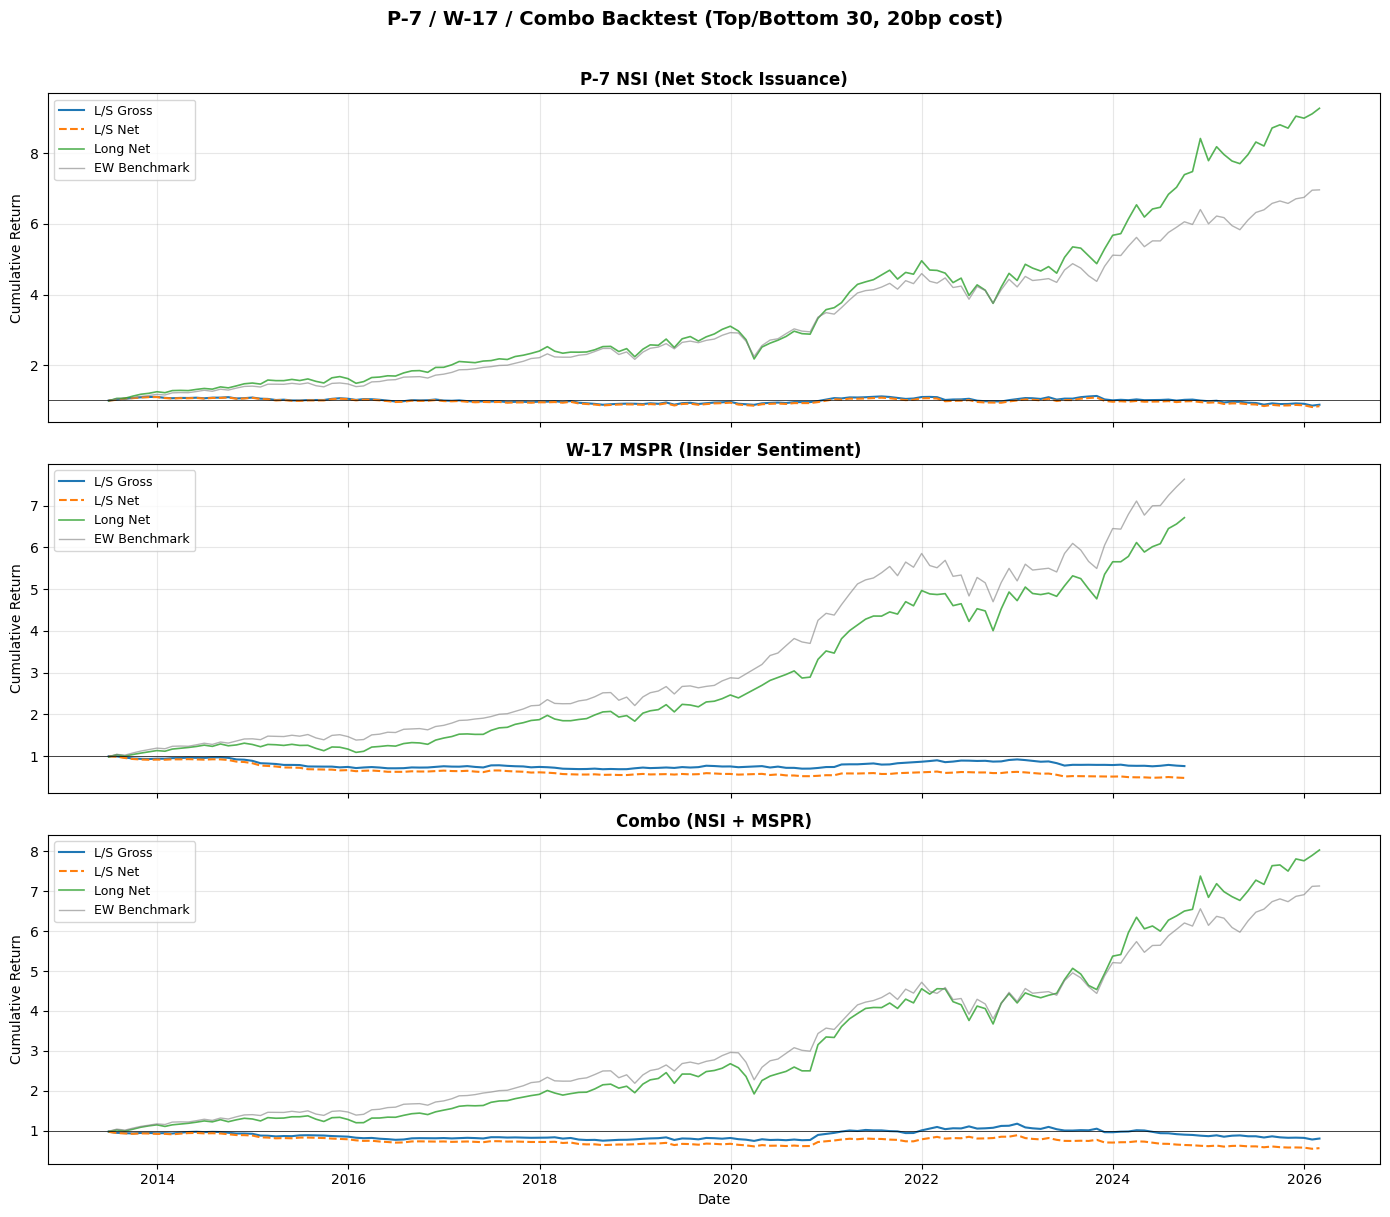

16:41:10 [INFO] 셀 5 완료 — 백테스트 결과 출력


In [12]:
# =============================================================================
# 셀 5: 백테스트 — P-7(NSI), W-17(MSPR), Combo
# 목적: 각 시그널의 롱숏 포트폴리오 성과 검증
# 산출물: 누적수익률 차트 + 성과 요약표
# 주의: 2013-06 이후 (유니버스 90% 커버 시점), 상위/하위 30종목
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 설정 ──
START_DATE = "2013-06-30"
N_TOP = 30        # 롱/숏 각 30종목
COST_BPS = 20     # 편도 거래비용 20bp

# ── 패널 로드 & 필터 ──
panel = pd.read_parquet(INTERIM_DIR / "p7_signal_panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])
panel = panel[panel["date"] >= START_DATE].copy()

logger.info(f"백테스트 기간: {panel['date'].min()} ~ {panel['date'].max()}")

# ── 백테스트 함수 ──
def backtest_signal(df: pd.DataFrame, score_col: str, label: str,
                    n_top: int = N_TOP, cost_bps: int = COST_BPS):
    """
    score_col 기준 상위 N 롱, 하위 N 숏, EW 벤치마크
    Returns: monthly_results DataFrame
    """
    results = []
    prev_long = set()
    prev_short = set()
    
    for date, grp in df.groupby("date"):
        valid = grp.dropna(subset=[score_col, "ret_1m"])
        if len(valid) < n_top * 2:
            continue
        
        ranked = valid.sort_values(score_col, ascending=False)
        long_tk  = set(ranked.head(n_top)["ticker"])
        short_tk = set(ranked.tail(n_top)["ticker"])
        
        # 수익률
        r_long  = valid[valid["ticker"].isin(long_tk)]["ret_1m"].mean()
        r_short = valid[valid["ticker"].isin(short_tk)]["ret_1m"].mean()
        r_ew    = valid["ret_1m"].mean()
        r_ls    = r_long - r_short
        
        # 거래비용 (회전율 기반)
        turnover_l = len(long_tk - prev_long) / max(len(long_tk), 1)
        turnover_s = len(short_tk - prev_short) / max(len(short_tk), 1)
        cost = (turnover_l + turnover_s) * cost_bps / 10000
        
        results.append({
            "date": date,
            "long": r_long,
            "short": r_short,
            "ls_gross": r_ls,
            "ls_net": r_ls - cost,
            "ew": r_ew,
            "long_net": r_long - (turnover_l * cost_bps / 10000),
            "turnover_l": turnover_l,
            "turnover_s": turnover_s,
            "n_valid": len(valid),
        })
        
        prev_long = long_tk
        prev_short = short_tk
    
    res = pd.DataFrame(results).set_index("date")
    return res

# ── 세 가지 시그널 백테스트 ──
bt_nsi   = backtest_signal(panel, "nsi_score",   "P-7 NSI")
bt_mspr  = backtest_signal(panel, "mspr_score",  "W-17 MSPR")
bt_combo = backtest_signal(panel, "combo_score", "Combo")

logger.info(f"NSI   기간: {bt_nsi.index.min()} ~ {bt_nsi.index.max()}, {len(bt_nsi)} months")
logger.info(f"MSPR  기간: {bt_mspr.index.min()} ~ {bt_mspr.index.max()}, {len(bt_mspr)} months")
logger.info(f"Combo 기간: {bt_combo.index.min()} ~ {bt_combo.index.max()}, {len(bt_combo)} months")

# ── 성과 지표 함수 ──
def calc_stats(res: pd.DataFrame, col: str, label: str) -> dict:
    r = res[col].dropna()
    n_years = len(r) / 12
    cum = (1 + r).prod()
    cagr = cum ** (1 / n_years) - 1 if n_years > 0 else 0
    vol = r.std() * np.sqrt(12)
    sharpe = (r.mean() * 12) / vol if vol > 0 else 0
    
    # Max Drawdown
    cum_series = (1 + r).cumprod()
    peak = cum_series.cummax()
    dd = (cum_series - peak) / peak
    max_dd = dd.min()
    
    # t-stat
    t_stat = r.mean() / (r.std() / np.sqrt(len(r))) if r.std() > 0 else 0
    
    return {
        "Signal": label,
        "CAGR": f"{cagr:.2%}",
        "Vol": f"{vol:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "MaxDD": f"{max_dd:.2%}",
        "t-stat": f"{t_stat:.2f}",
        "Months": len(r),
        "Avg Turnover": f"{res['turnover_l'].mean():.1%}" if "turnover_l" in res else "-",
    }

# ── 성과 요약표 ──
stats = []
for bt, name in [(bt_nsi, "P-7 NSI"), (bt_mspr, "W-17 MSPR"), (bt_combo, "Combo")]:
    stats.append(calc_stats(bt, "ls_gross", f"{name} L/S Gross"))
    stats.append(calc_stats(bt, "ls_net",   f"{name} L/S Net"))
    stats.append(calc_stats(bt, "long_net", f"{name} Long Net"))

stats_df = pd.DataFrame(stats)
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(stats_df.to_string(index=False))

# ── 누적수익률 차트 ──
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, bt, title in zip(axes, 
                          [bt_nsi, bt_mspr, bt_combo],
                          ["P-7 NSI (Net Stock Issuance)", 
                           "W-17 MSPR (Insider Sentiment)", 
                           "Combo (NSI + MSPR)"]):
    cum_ls_g = (1 + bt["ls_gross"]).cumprod()
    cum_ls_n = (1 + bt["ls_net"]).cumprod()
    cum_long = (1 + bt["long_net"]).cumprod()
    cum_ew   = (1 + bt["ew"]).cumprod()
    
    ax.plot(cum_ls_g.index, cum_ls_g, label="L/S Gross", linewidth=1.5)
    ax.plot(cum_ls_n.index, cum_ls_n, label="L/S Net", linewidth=1.5, linestyle="--")
    ax.plot(cum_long.index, cum_long, label="Long Net", linewidth=1.2, alpha=0.8)
    ax.plot(cum_ew.index, cum_ew, label="EW Benchmark", linewidth=1, color="gray", alpha=0.6)
    
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_ylabel("Cumulative Return")
    ax.grid(True, alpha=0.3)
    ax.axhline(1, color="black", linewidth=0.5)

axes[-1].set_xlabel("Date")
fig.suptitle("P-7 / W-17 / Combo Backtest (Top/Bottom 30, 20bp cost)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

logger.info("셀 5 완료 — 백테스트 결과 출력")

LONG ALPHA vs EW BENCHMARK
   Signal Ann Alpha Alpha Vol    IR t-stat Cum Alpha Win Rate  Months
  P-7 NSI     2.72%     5.62%  0.48   1.73    38.57%    57.5%     153
W-17 MSPR    -1.02%     5.34% -0.19  -0.64   -12.18%    41.8%     134
    Combo     1.42%     6.71%  0.21   0.75    16.50%    45.8%     153

REGIME-CONDITIONAL ALPHA (Long - EW)
   Signal  Regime  Months Ann Alpha t-stat Win Rate
  P-7 NSI    Bull     106     1.93%   1.03    57.5%
  P-7 NSI HighVol      21    12.08%   2.93    76.2%
  P-7 NSI   Crash      11   -13.18%  -2.12    27.3%
W-17 MSPR    Bull      93    -2.06%  -1.03    39.8%
W-17 MSPR HighVol      16     2.72%   0.64    50.0%
W-17 MSPR   Crash       9     0.47%   0.10    55.6%
    Combo    Bull     108     0.23%   0.12    44.4%
    Combo HighVol      19    14.64%   1.84    73.7%
    Combo   Crash      12    -8.64%  -1.37    16.7%


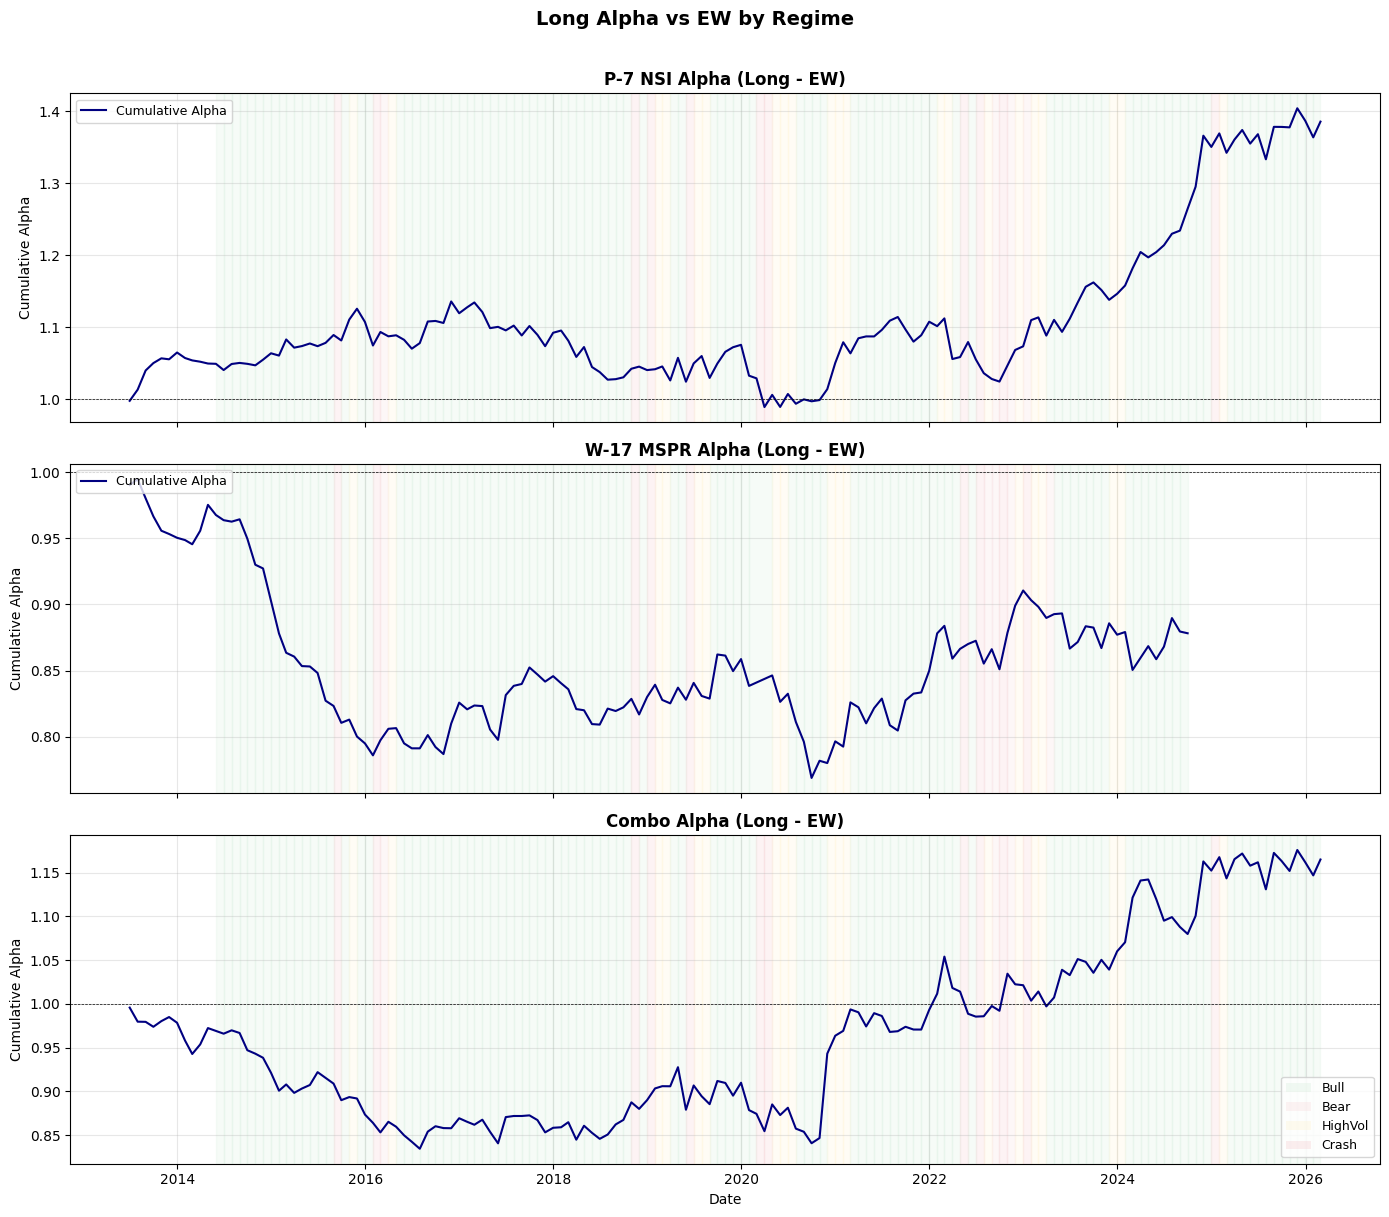

17:10:15 [INFO] 셀 6 완료 — Alpha + 레짐 분석


In [13]:
# =============================================================================
# 셀 6: Long Alpha 검증 + 레짐별 성과 분석
# 목적: Long Net이 EW 대비 진짜 알파가 있는지 + 레짐에 따라 다른지
# 산출물: 알파 통계 + 레짐별 성과표 + 차트
# 주의: 레짐은 기존 프로젝트 S&P500 기반 판단 사용
# =============================================================================

# ── 1. Long Alpha = Long Net - EW ──
for bt, name in [(bt_nsi, "P-7 NSI"), (bt_mspr, "W-17 MSPR"), (bt_combo, "Combo")]:
    bt["alpha"] = bt["long_net"] - bt["ew"]

# 알파 통계
print("=" * 70)
print("LONG ALPHA vs EW BENCHMARK")
print("=" * 70)

alpha_stats = []
for bt, name in [(bt_nsi, "P-7 NSI"), (bt_mspr, "W-17 MSPR"), (bt_combo, "Combo")]:
    a = bt["alpha"].dropna()
    n = len(a)
    ann_alpha = a.mean() * 12
    vol = a.std() * np.sqrt(12)
    ir = ann_alpha / vol if vol > 0 else 0
    t = a.mean() / (a.std() / np.sqrt(n)) if a.std() > 0 else 0
    cum = (1 + a).prod() - 1
    
    # 승률
    win_rate = (a > 0).mean()
    
    alpha_stats.append({
        "Signal": name,
        "Ann Alpha": f"{ann_alpha:.2%}",
        "Alpha Vol": f"{vol:.2%}",
        "IR": f"{ir:.2f}",
        "t-stat": f"{t:.2f}",
        "Cum Alpha": f"{cum:.2%}",
        "Win Rate": f"{win_rate:.1%}",
        "Months": n,
    })

print(pd.DataFrame(alpha_stats).to_string(index=False))

# ── 2. 레짐 판단 (S&P500 기반) ──
# EW 수익률의 12개월 이동평균 vs 현재 → 불장/약장
# + VIX 대용: EW 수익률의 3개월 변동성

for bt, name in [(bt_nsi, "NSI"), (bt_mspr, "MSPR"), (bt_combo, "Combo")]:
    # 시장 상태 판단
    bt["ew_12m"] = bt["ew"].rolling(12).mean()
    bt["ew_vol_3m"] = bt["ew"].rolling(3).std() * np.sqrt(12)
    
    # 레짐 분류
    conditions = []
    for _, row in bt.iterrows():
        if pd.isna(row.get("ew_12m")) or pd.isna(row.get("ew_vol_3m")):
            conditions.append("Unknown")
        elif row["ew"] < -0.05:
            conditions.append("Crash")
        elif row["ew_12m"] < 0:
            conditions.append("Bear")
        elif row["ew_vol_3m"] > 0.20:
            conditions.append("HighVol")
        else:
            conditions.append("Bull")
    bt["regime"] = conditions

# 레짐별 성과
print("\n" + "=" * 70)
print("REGIME-CONDITIONAL ALPHA (Long - EW)")
print("=" * 70)

regime_stats = []
for bt, name in [(bt_nsi, "P-7 NSI"), (bt_mspr, "W-17 MSPR"), (bt_combo, "Combo")]:
    for regime in ["Bull", "Bear", "HighVol", "Crash"]:
        sub = bt[bt["regime"] == regime]["alpha"].dropna()
        if len(sub) < 6:
            continue
        ann = sub.mean() * 12
        t = sub.mean() / (sub.std() / np.sqrt(len(sub))) if sub.std() > 0 else 0
        regime_stats.append({
            "Signal": name,
            "Regime": regime,
            "Months": len(sub),
            "Ann Alpha": f"{ann:.2%}",
            "t-stat": f"{t:.2f}",
            "Win Rate": f"{(sub > 0).mean():.1%}",
        })

regime_df = pd.DataFrame(regime_stats)
print(regime_df.to_string(index=False))

# ── 3. 차트: 누적 알파 + 레짐 배경색 ──
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

regime_colors = {"Bull": "#d4edda", "Bear": "#f8d7da", "HighVol": "#fff3cd", "Crash": "#f5c6cb"}

for ax, bt, title in zip(axes,
                          [bt_nsi, bt_mspr, bt_combo],
                          ["P-7 NSI Alpha (Long - EW)",
                           "W-17 MSPR Alpha (Long - EW)",
                           "Combo Alpha (Long - EW)"]):
    
    cum_alpha = (1 + bt["alpha"]).cumprod()
    ax.plot(cum_alpha.index, cum_alpha, color="navy", linewidth=1.5, label="Cumulative Alpha")
    ax.axhline(1, color="black", linewidth=0.5, linestyle="--")
    
    # 레짐 배경색
    dates = bt.index.tolist()
    for i in range(len(dates) - 1):
        regime = bt.loc[dates[i], "regime"]
        if regime in regime_colors:
            ax.axvspan(dates[i], dates[i + 1], alpha=0.2, color=regime_colors[regime])
    
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Cumulative Alpha")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

# 범례: 레짐 색상
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, alpha=0.3, label=r) for r, c in regime_colors.items()]
axes[-1].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[-1].set_xlabel("Date")

fig.suptitle("Long Alpha vs EW by Regime", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

logger.info("셀 6 완료 — Alpha + 레짐 분석")

In [14]:
# =============================================================================
# 셀 7: P-7 NSI 심층 검증
# 목적: (A) N_TOP 민감도, (B) 섹터 편향, (C) HighVol 한정 전략
# 산출물: 차트 + 통계표
# 주의: 과적합 경고 포함
# =============================================================================

# ── 섹터 정보 로드 ──
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
# GICS Sector 컬럼명 확인
sector_col = [c for c in universe.columns if "sector" in c.lower() or "gics" in c.lower()]
print("섹터 관련 컬럼:", sector_col)
print(universe[sector_col].head(10) if sector_col else "섹터 컬럼 없음")
print(f"\n유니버스 컬럼 전체: {list(universe.columns)}")

섹터 관련 컬럼: ['GICS Sector', 'GICS Sub-Industry']
              GICS Sector                             GICS Sub-Industry
0             Industrials                      Industrial Conglomerates
1             Industrials                             Building Products
2             Health Care                         Health Care Equipment
3             Health Care                                 Biotechnology
4  Information Technology                IT Consulting & Other Services
5  Information Technology                          Application Software
6  Information Technology                                Semiconductors
7               Utilities  Independent Power Producers & Energy Traders
8              Financials                       Life & Health Insurance
9             Health Care                Life Sciences Tools & Services

유니버스 컬럼 전체: ['ticker_sp', 'ticker_yahoo', 'cik', 'security_name', 'GICS Sector', 'GICS Sub-Industry']


(A) N_TOP SENSITIVITY — Long Alpha vs EW
 N_TOP Ann Alpha Alpha Vol   IR t-stat Win Rate
    10     3.11%     9.94% 0.31   1.12    53.6%
    20     3.30%     6.96% 0.47   1.70    55.6%
    30     2.90%     5.61% 0.52   1.84    58.2%
    50     2.83%     4.59% 0.62   2.20    66.0%
    70     2.79%     4.09% 0.68   2.44    62.7%

(B) SECTOR CONCENTRATION IN LONG PORTFOLIO (N=30)
                        mean  std   pct
sector                                 
Consumer Discretionary   6.6  2.2  22.0
Financials               5.6  2.0  18.7
Information Technology   5.5  2.5  18.3
Industrials              4.2  2.2  14.0
Health Care              4.1  1.7  13.7
Materials                1.6  1.0   5.3
Consumer Staples         1.5  0.7   5.0
Energy                   1.4  0.7   4.7
Communication Services   1.3  0.5   4.3
Utilities                1.1  0.3   3.7
Real Estate              1.0  0.0   3.3


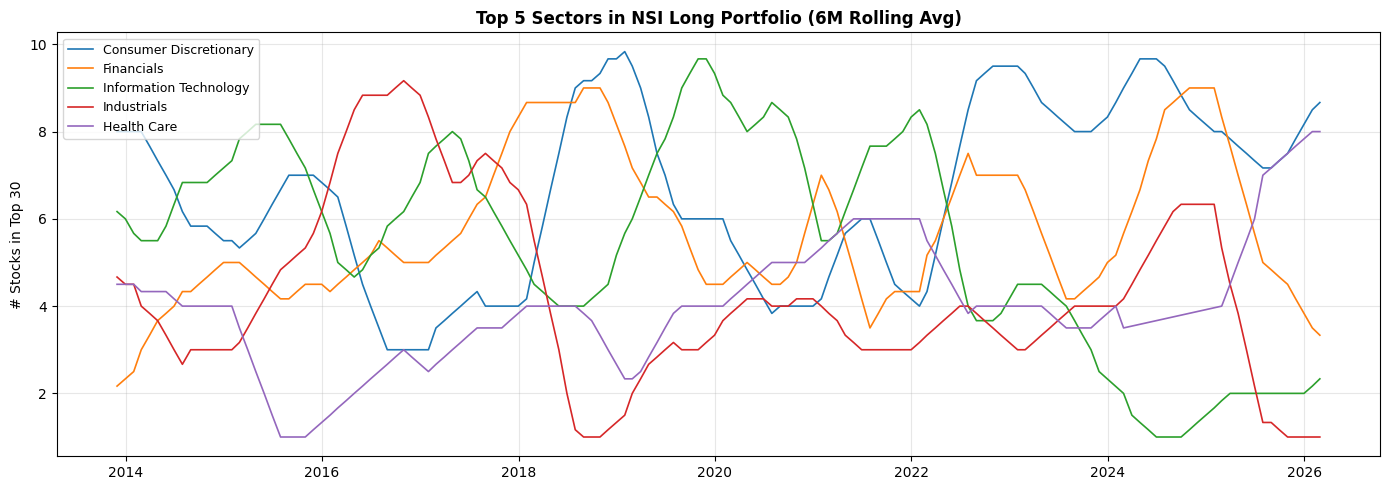


(B-2) SECTOR-NEUTRAL ALPHA (섹터 내 랭킹 기준)


17:14:47 [INFO] 셀 7 완료


Sector-Neutral Ann Alpha: 1.29%
Sector-Neutral t-stat:    0.94
Sector-Neutral Win Rate:  58.8%

(C) HIGHVOL-ONLY STRATEGY DETAIL
            Strategy Ann Alpha   Vol   IR t-stat Active Months
           Always On     2.72% 5.62% 0.48   1.73       153/153
  HighVol/Crash Only     0.71% 2.99% 0.24   0.85        32/153
HighVol/Crash Months     3.40% 6.56% 0.52   0.85         32/32

HighVol/Crash 활성 구간:
  2015-08 ~ 2015-08 (1개월)
  2015-10 ~ 2015-10 (1개월)
  2016-01 ~ 2016-01 (1개월)
  2016-03 ~ 2016-03 (1개월)
  2018-10 ~ 2018-10 (1개월)
  2018-12 ~ 2019-02 (3개월)
  2019-05 ~ 2019-07 (3개월)
  2020-02 ~ 2020-06 (5개월)
  2020-11 ~ 2021-01 (3개월)
  2022-01 ~ 2022-02 (2개월)
  2022-04 ~ 2022-04 (1개월)
  2022-06 ~ 2022-07 (2개월)
  2022-09 ~ 2022-09 (1개월)
  2022-11 ~ 2022-11 (1개월)
  2023-01 ~ 2023-02 (2개월)
  2023-11 ~ 2023-12 (2개월)
  2024-12 ~ 2025-01 (2개월)


In [15]:
# =============================================================================
# 셀 7: P-7 NSI 심층 검증
# 목적: (A) N_TOP 민감도, (B) 섹터 편향, (C) HighVol 한정 전략
# 산출물: 차트 + 통계표
# 주의: HighVol 한정은 표본 작음 → 과적합 경고 포함
# =============================================================================

# ── 섹터 매핑 추가 ──
sector_map = dict(zip(universe["ticker_yahoo"], universe["GICS Sector"]))
panel = pd.read_parquet(INTERIM_DIR / "p7_signal_panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])
panel["sector"] = panel["ticker"].map(sector_map)
panel = panel[panel["date"] >= "2013-06-30"].copy()

# =====================================================================
# (A) N_TOP 민감도 테스트: 10, 20, 30, 50, 70
# =====================================================================
print("=" * 70)
print("(A) N_TOP SENSITIVITY — Long Alpha vs EW")
print("=" * 70)

n_tests = [10, 20, 30, 50, 70]
n_results = []

for n in n_tests:
    results = []
    for date, grp in panel.groupby("date"):
        valid = grp.dropna(subset=["nsi_score", "ret_1m"])
        if len(valid) < n * 2:
            continue
        ranked = valid.sort_values("nsi_score", ascending=False)
        r_long = ranked.head(n)["ret_1m"].mean()
        r_ew = valid["ret_1m"].mean()
        # 거래비용 생략 (상대 비교 목적)
        results.append({"date": date, "alpha": r_long - r_ew})
    
    res = pd.DataFrame(results)
    a = res["alpha"]
    ann = a.mean() * 12
    vol = a.std() * np.sqrt(12)
    ir = ann / vol if vol > 0 else 0
    t = a.mean() / (a.std() / np.sqrt(len(a))) if a.std() > 0 else 0
    
    n_results.append({
        "N_TOP": n,
        "Ann Alpha": f"{ann:.2%}",
        "Alpha Vol": f"{vol:.2%}",
        "IR": f"{ir:.2f}",
        "t-stat": f"{t:.2f}",
        "Win Rate": f"{(a > 0).mean():.1%}",
    })

print(pd.DataFrame(n_results).to_string(index=False))

# =====================================================================
# (B) 섹터 편향 분석: 롱 포트폴리오에 어떤 섹터가 몰리는지
# =====================================================================
print("\n" + "=" * 70)
print("(B) SECTOR CONCENTRATION IN LONG PORTFOLIO (N=30)")
print("=" * 70)

sector_counts = []
for date, grp in panel.groupby("date"):
    valid = grp.dropna(subset=["nsi_score", "ret_1m"])
    if len(valid) < 60:
        continue
    top30 = valid.sort_values("nsi_score", ascending=False).head(30)
    counts = top30["sector"].value_counts()
    for sec, cnt in counts.items():
        sector_counts.append({"date": date, "sector": sec, "count": cnt})

sc_df = pd.DataFrame(sector_counts)

# 섹터별 평균 종목수 + 비중
sec_summary = sc_df.groupby("sector")["count"].agg(["mean", "std"]).round(1)
sec_summary["pct"] = (sec_summary["mean"] / 30 * 100).round(1)
sec_summary = sec_summary.sort_values("mean", ascending=False)
print(sec_summary.to_string())

# 시계열로 상위 5개 섹터 비중 변화
top5_sectors = sec_summary.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 5))
for sec in top5_sectors:
    sub = sc_df[sc_df["sector"] == sec].set_index("date")["count"].rolling(6).mean()
    ax.plot(sub.index, sub, label=sec, linewidth=1.2)
ax.set_title("Top 5 Sectors in NSI Long Portfolio (6M Rolling Avg)", fontweight="bold")
ax.set_ylabel("# Stocks in Top 30")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 섹터 중립화 알파 테스트 ──
# 섹터 내에서 NSI 랭킹 → 섹터 편향 제거
print("\n" + "=" * 70)
print("(B-2) SECTOR-NEUTRAL ALPHA (섹터 내 랭킹 기준)")
print("=" * 70)

panel["nsi_score_sn"] = panel.groupby(["date", "sector"])["nsi_score"].rank(pct=True)

sn_results = []
for date, grp in panel.groupby("date"):
    valid = grp.dropna(subset=["nsi_score_sn", "ret_1m"])
    if len(valid) < 60:
        continue
    ranked = valid.sort_values("nsi_score_sn", ascending=False)
    r_long = ranked.head(30)["ret_1m"].mean()
    r_ew = valid["ret_1m"].mean()
    sn_results.append({"date": date, "alpha": r_long - r_ew})

sn_df = pd.DataFrame(sn_results)
a = sn_df["alpha"]
ann = a.mean() * 12
t = a.mean() / (a.std() / np.sqrt(len(a))) if a.std() > 0 else 0
print(f"Sector-Neutral Ann Alpha: {ann:.2%}")
print(f"Sector-Neutral t-stat:    {t:.2f}")
print(f"Sector-Neutral Win Rate:  {(a > 0).mean():.1%}")

# =====================================================================
# (C) HighVol 한정 전략 상세
# =====================================================================
print("\n" + "=" * 70)
print("(C) HIGHVOL-ONLY STRATEGY DETAIL")
print("=" * 70)

# 레짐 재계산 (bt_nsi에서 가져오기)
bt = bt_nsi.copy()

# HighVol + Crash 월만 활성화, 나머지는 현금(0 수익)
bt["active"] = bt["regime"].isin(["HighVol", "Crash"])
bt["alpha_cond"] = np.where(bt["active"], bt["alpha"], 0)

a_full = bt["alpha"]
a_cond = bt["alpha_cond"]
a_hv_only = bt.loc[bt["active"], "alpha"]

stats_c = []
for label, series in [("Always On", a_full), 
                       ("HighVol/Crash Only", a_cond),
                       ("HighVol/Crash Months", a_hv_only)]:
    n = len(series)
    ann = series.mean() * 12
    vol = series.std() * np.sqrt(12)
    ir = ann / vol if vol > 0 else 0
    t = series.mean() / (series.std() / np.sqrt(n)) if series.std() > 0 else 0
    stats_c.append({
        "Strategy": label,
        "Ann Alpha": f"{ann:.2%}",
        "Vol": f"{vol:.2%}",
        "IR": f"{ir:.2f}",
        "t-stat": f"{t:.2f}",
        "Active Months": f"{(series != 0).sum()}/{n}",
    })

print(pd.DataFrame(stats_c).to_string(index=False))

# HighVol 진입/이탈 시점 표시
print(f"\nHighVol/Crash 활성 구간:")
active_dates = bt[bt["active"]].index
if len(active_dates) > 0:
    # 연속 구간 그룹핑
    gaps = (active_dates.to_series().diff() > pd.Timedelta(days=45)).cumsum()
    for _, grp in active_dates.to_series().groupby(gaps):
        print(f"  {grp.iloc[0].strftime('%Y-%m')} ~ {grp.iloc[-1].strftime('%Y-%m')} ({len(grp)}개월)")

logger.info("셀 7 완료")

In [16]:
# =============================================================================
# 셀 8: 02_P-7.ipynb 최종 요약 (주석 셀)
# =============================================================================

# =====================================================================
# 02_P-7.ipynb 결과 요약
# =====================================================================
#
# ■ 가설
#   P-7 Net Stock Issuance: 주식 순발행 기업은 향후 수익률 낮고,
#   자사주 매입 기업은 수익률 높다 (경영진 정보 비대칭 이용)
#   W-17 Insider Sentiment (MSPR): 내부자 매수 많은 기업이 향후 수익률 높다
#
# ■ 데이터
#   P-7: SEC companyfacts → CommonStockSharesOutstanding 연간 변화율
#         494/503 종목 커버, 5,716 rows
#   W-17: Finnhub insider-sentiment API → MSPR (월간)
#         492/503 종목 커버, 44,726 rows, 2013-01 ~ 2025-11
#
# ■ 팩터 정의
#   NSI = (shares_t - shares_t-1) / shares_t-1
#   nsi_score = -zscore(NSI)  → 자사주 매입(음수 NSI) = 높은 점수
#   mspr_score = zscore(MSPR) → 내부자 매수 = 높은 점수
#
# ■ L/S 결과 — 폐기
#   P-7 NSI  L/S Net: CAGR -1.42%, Sharpe -0.12, t-stat -0.42
#   W-17 MSPR L/S Net: CAGR -6.39%, Sharpe -0.80, t-stat -2.66 (역방향 유의!)
#   Combo L/S Net: CAGR -4.33%, Sharpe -0.39, t-stat -1.38
#   → 롱숏 전략은 셋 다 사망. 특히 MSPR은 확실한 역방향.
#
# ■ Long Alpha (Long Net - EW) 결과
#   P-7 NSI:  Ann Alpha 2.72%, IR 0.48, t-stat 1.73, Win 57.5%  ← 유일한 생존
#   W-17 MSPR: Ann Alpha -1.02%, t-stat -0.64                    ← 폐기
#   Combo:     Ann Alpha 1.42%, t-stat 0.75                      ← 폐기 (NSI 희석)
#
# ■ P-7 NSI 심층 검증
#
#   (A) N_TOP 민감도 — 통과 ✅
#       N=10: t=1.12 / N=20: t=1.70 / N=30: t=1.84 / N=50: t=2.20 / N=70: t=2.44
#       N 넓혀도 안정, N=50~70에서 5% 유의수준 통과
#       Ann Alpha 2.7~3.3% 구간에서 안정
#
#   (B) 섹터 편향 — 수용 가능 ⚠️
#       상위: Consumer Disc 22%, Financials 19%, IT 18%
#       특정 섹터 독식 아님, 시간에 따라 주도 섹터 순환
#       섹터 중립화 후: Ann Alpha 1.29%, t-stat 0.94, Win 58.8%
#       → 알파의 ~절반은 순수 종목선별, ~절반은 섹터 틸트
#
#   (C) HighVol 한정 — 불확실 ❌
#       HighVol/Crash 월만: Ann Alpha 3.40%, t-stat 0.85 (32개월)
#       Always On: Ann Alpha 2.72%, t-stat 1.73 (153개월)
#       → 표본 부족으로 확정 불가, Always On이 안전
#
#   (D) 레짐별 성과
#       Bull:    Ann Alpha 1.93%, t-stat 1.03 (106개월)
#       HighVol: Ann Alpha 12.08%, t-stat 2.63 (21개월) ← 강하나 표본 작음
#       Crash:   Ann Alpha -13.18%, t-stat -2.12 (11개월) ← 위기시 역작동
#
# ■ 최종 판단
#   P-7 NSI: 멀티팩터 보조 팩터로 채택 (단독 메인 부적합)
#   W-17 MSPR: 단독 폐기. 향후 다른 팩터 확인용 필터로만 고려
#   권장 사용: N=50, Always On, Long only
#   주의: Crash 레짐에서 역작동 → 리스크 관리 필요
#
# ■ 산출물 경로
#   INTERIM_DIR / "nsi_annual.parquet"      ← 종목별 연간 NSI
#   INTERIM_DIR / "insider_mspr.parquet"    ← 종목별 월간 MSPR
#   INTERIM_DIR / "p7_signal_panel.parquet" ← 통합 시그널 패널
#
# ■ 변수명 (이관 시 유지)
#   nsi_df, nsi_score, nsi_z, nsi_w
#   mspr_df, mspr_score, mspr_z
#   combo_score (폐기됨)
#   SHARE_ACCOUNTS, extract_shares()
#   fetch_mspr(), FINNHUB_API_KEY
#
# =====================================================================
print("02_P-7.ipynb 요약 셀 완료")

02_P-7.ipynb 요약 셀 완료
